In [1]:
import kagglehub
from pathlib import Path
from fastcore.all import *
from fastai.vision.all import *

In [2]:
resized_dataset_path = kagglehub.dataset_download('aviramsiginur/resized-dataset')
resized_dataset_path

'/kaggle/input/datasets/aviramsiginur/resized-dataset'

In [3]:
failed = verify_images(get_image_files(resized_dataset_path))
len(failed)

0

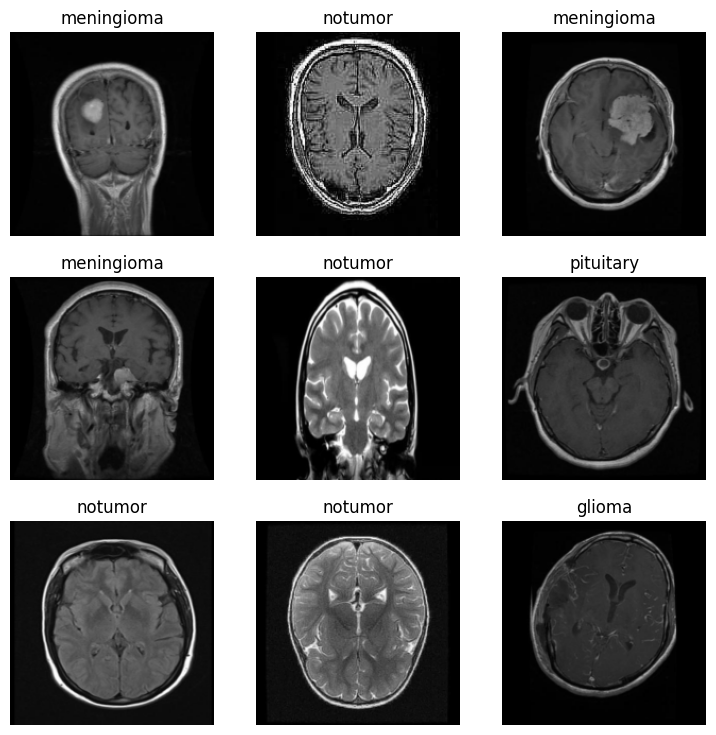

In [4]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Training', valid_name='Testing'),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(resized_dataset_path)

dls.show_batch(max_n=9)

In [5]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.733621,0.658433,0.158750,00:15


epoch,train_loss,valid_loss,error_rate,time
0,0.282505,0.483849,0.086875,00:16
1,0.104612,0.393146,0.066250,00:16


> In the 3rd epoch, both the validation loss and error_rate raised a bit, which probably means that the model is overfitted, so I decided to change the number of epochs to 2.

In [6]:
is_meningioma, _, probs = learn.predict('/kaggle/input/datasets/aviramsiginur/random-meningioma-scan/brain_with_meningioma.jpeg')
print(f'This is a brain with {is_meningioma}')
print(f'Probability it\'s a brain with meningioma tumor: {probs[1]:.3f}')

This is a brain with meningioma
Probability it's a brain with meningioma tumor: 0.993
